In [1]:
import csv
import codecs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from sklearn.impute import SimpleImputer
# 注意：如果使用impute库需要先安装：pip install impute
# from impute import em, fast_knn

In [2]:
# ---------------------- 1. 导入与读取数据 ----------------------
file_path = "F:\\AAAAAAAAAAAAAAAAAAAAA\\Senior\\subject\\数据挖掘\\diabetes(1)\\diabetes_data_upload.csv"
try:
    # 读取数据并只保留Age列
    df = pd.read_csv(file_path)
    age_data = df[['Age']].copy()  # 提取Age列并转为DataFrame
    print("数据读取成功！")
    print("前5行数据:\n", age_data.head(), "\n数据形状:", age_data.shape)
except FileNotFoundError:
    print(f"错误：文件 {file_path} 未找到")
    exit()
except Exception as e:
    print(f"读取数据出错：{e}")
    exit()

数据读取成功！
前5行数据:
    Age
0   40
1   58
2   41
3   45
4   60 
数据形状: (520, 1)


In [3]:
# ---------------------- 2. 数据基本查看 ----------------------
print("\n---------------------- 数据基本信息 ----------------------")
print("前5行数据:")
print(age_data.head())
print("\n数据信息:")
print(age_data.info())
print("\n数据形状:", age_data.shape)
print("\n描述性统计:")
print(age_data.describe())


---------------------- 数据基本信息 ----------------------
前5行数据:
   Age
0   40
1   58
2   41
3   45
4   60

数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     520 non-null    int64
dtypes: int64(1)
memory usage: 4.2 KB
None

数据形状: (520, 1)

描述性统计:
              Age
count  520.000000
mean    48.028846
std     12.151466
min     16.000000
25%     39.000000
50%     47.500000
75%     57.000000
max     90.000000


In [15]:
# ---------------------- 3. 统计量计算（均值、中位数、方差等） ----------------------
print("\n---------------------- 统计量计算 ----------------------")
# 提取为numpy数组便于计算
age_array = age_data['Age'].values

mean = np.mean(age_array)  # 均值
median = np.median(age_array)  # 中位数
mode_result = stats.mode(age_array)  # 众数

# 修复：直接获取标量众数值，无需索引
argmax = mode_result.mode if mode_result.mode.size > 0 else None

# 可选：如果需要确保是Python原生类型（如int），可以使用item()方法
# argmax = mode_result.mode.item() if mode_result.mode.size > 0 else None

arrvar = np.var(age_array)  # 方差
arrstd = np.std(age_array, ddof=1)  # 标准差（样本标准差）
maxnum = np.max(age_array)  # 最大值
minnum = np.min(age_array)  # 最小值

print(f"均值为：{mean:.3f}")
print(f"中位数为：{median:.3f}")
print(f"众数为：{argmax}")
print(f"方差为：{arrvar:.3f}")
print(f"标准差为：{arrstd:.3f}")
print(f"最大值为：{maxnum}")
print(f"最小值为：{minnum}")
    


---------------------- 统计量计算 ----------------------
均值为：48.029
中位数为：47.500
众数为：35
方差为：147.374
标准差为：12.151
最大值为：90
最小值为：16



---------------------- 绘制箱线图 ----------------------


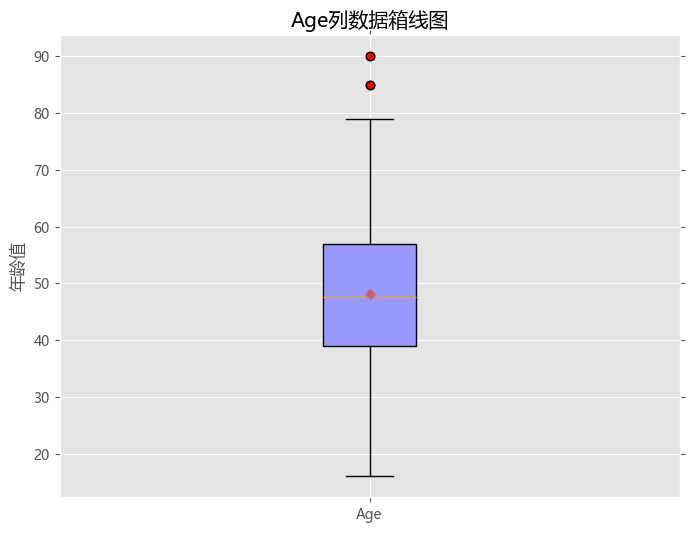

In [6]:
# ---------------------- 4. 绘制箱线图（Boxplot） ----------------------
print("\n---------------------- 绘制箱线图 ----------------------")
# 设置中文显示
plt.style.use('ggplot')
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
plt.boxplot(
    x=age_data['Age'],
    patch_artist=True,  # 允许填充颜色
    showmeans=True,  # 显示均值
    boxprops={'color': 'black', 'facecolor': '#9999ff'},
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'color': 'black'},
    meanprops={'marker': 'D', 'markerfacecolor': 'indianred'},
    medianprops={'linestyle': '--', 'color': 'orange'}
)

plt.xticks([1], ["Age"])
plt.ylabel("年龄值")
plt.title("Age列数据箱线图")
plt.tick_params(top='off', right='off')
plt.show()


---------------------- 3σ原则检测异常值 ----------------------
正态性检验结果：统计量=0.0687, p值=0.0141
均值为：48.029，标准差为：12.151
3σ原则检测到的异常值共4条:
     Age
101   85
102   90
185   85
186   90


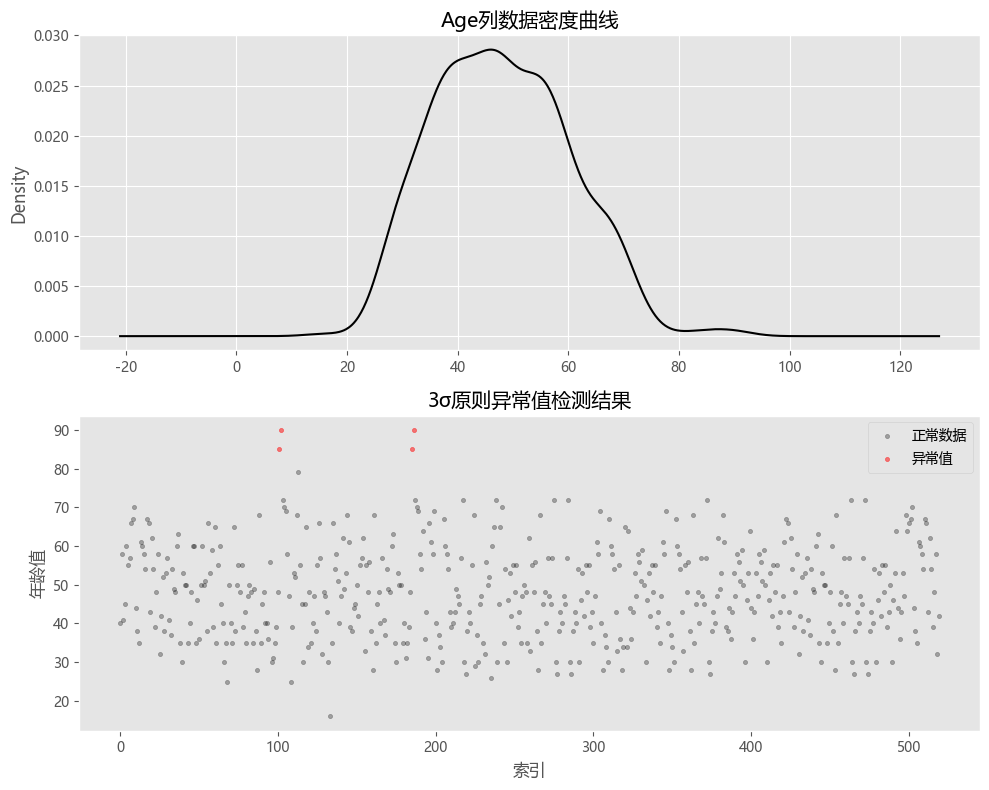

In [7]:
# ---------------------- 5. 3σ原则检测异常值 ----------------------
print("\n---------------------- 3σ原则检测异常值 ----------------------")
u = age_data['Age'].mean()  # 均值
std = age_data['Age'].std()  # 标准差

# 正态性检验
norm_test = stats.kstest(age_data['Age'], 'norm', (u, std))
print(f"正态性检验结果：统计量={norm_test.statistic:.4f}, p值={norm_test.pvalue:.4f}")
print(f"均值为：{u:.3f}，标准差为：{std:.3f}")

# 筛选异常值
error_3sigma = age_data[np.abs(age_data['Age'] - u) > 3 * std]
data_c_3sigma = age_data[np.abs(age_data['Age'] - u) <= 3 * std]
print(f"3σ原则检测到的异常值共{len(error_3sigma)}条:")
print(error_3sigma)

# 可视化
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(2, 1, 1)
age_data['Age'].plot(kind='kde', grid=True, style='-k', title='Age列数据密度曲线')

ax2 = fig.add_subplot(2, 1, 2)
plt.scatter(data_c_3sigma.index, data_c_3sigma['Age'], color='k', marker='.', alpha=0.3, label='正常数据')
plt.scatter(error_3sigma.index, error_3sigma['Age'], color='r', marker='.', alpha=0.5, label='异常值')
plt.xlabel("索引")
plt.ylabel("年龄值")
plt.title("3σ原则异常值检测结果")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


---------------------- 横向箱型图分析 ----------------------


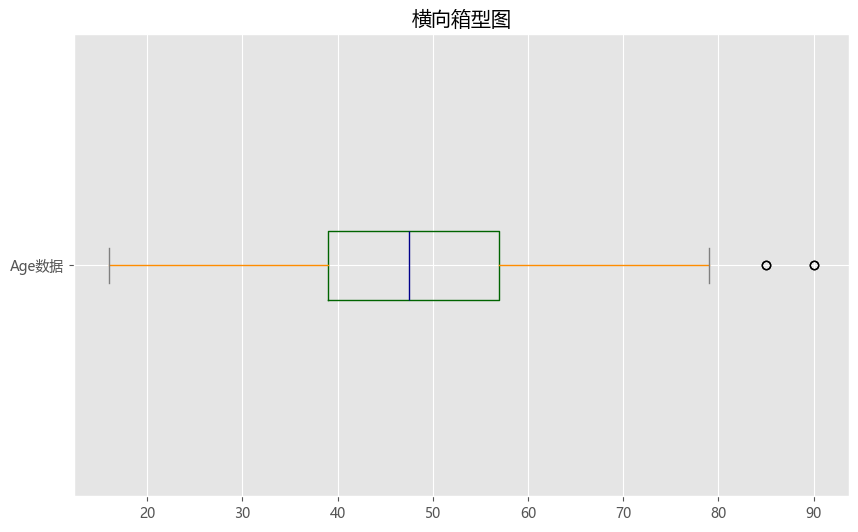

In [8]:
# ---------------------- 6. 箱型图（横向）分析异常值 ----------------------
print("\n---------------------- 横向箱型图分析 ----------------------")
plt.figure(figsize=(10, 6))
color = dict(boxes='DarkGreen', whiskers='DarkOrange', medians='DarkBlue', caps='Gray')
age_data['Age'].plot.box(vert=False, grid=True, color=color, label='Age数据', title='横向箱型图')
plt.show()


---------------------- IQR方法检测异常值 ----------------------
描述性统计结果:
count    520.000000
mean      48.028846
std       12.151466
min       16.000000
25%       39.000000
50%       47.500000
75%       57.000000
max       90.000000
Name: Age, dtype: float64
四分位差(IQR)为：18.000
异常值下限为：12.000，上限为：84.000
IQR方法检测到的异常值共4条:
     Age
101   85
102   90
185   85
186   90


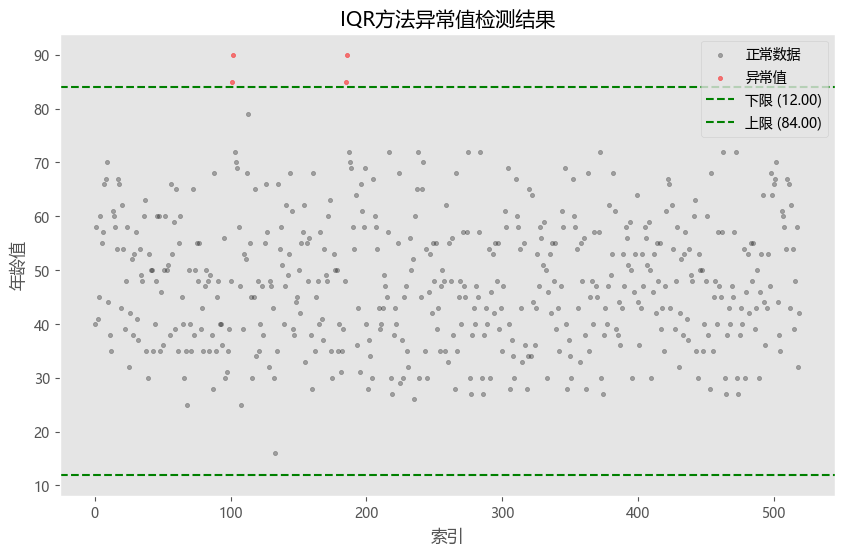

In [9]:
# ---------------------- 7. 分位数（IQR）检测异常值 ----------------------
print("\n---------------------- IQR方法检测异常值 ----------------------")
s = age_data['Age'].describe()
print("描述性统计结果:")
print(s)

# 计算分位数与上下限
q1 = s['25%']
q3 = s['75%']
iqr = q3 - q1
mi = q1 - 1.5 * iqr  # 下限
ma = q3 + 1.5 * iqr  # 上限

print(f"四分位差(IQR)为：{iqr:.3f}")
print(f"异常值下限为：{mi:.3f}，上限为：{ma:.3f}")

# 筛选异常值
error_iqr = age_data[(age_data['Age'] < mi) | (age_data['Age'] > ma)]
data_c_iqr = age_data[(age_data['Age'] >= mi) & (age_data['Age'] <= ma)]
print(f"IQR方法检测到的异常值共{len(error_iqr)}条:")
print(error_iqr)

# 可视化
plt.figure(figsize=(10, 6))
plt.scatter(data_c_iqr.index, data_c_iqr['Age'], color='k', marker='.', alpha=0.3, label='正常数据')
plt.scatter(error_iqr.index, error_iqr['Age'], color='r', marker='.', alpha=0.5, label='异常值')
plt.axhline(y=mi, color='g', linestyle='--', label=f'下限 ({mi:.2f})')
plt.axhline(y=ma, color='g', linestyle='--', label=f'上限 ({ma:.2f})')
plt.xlabel("索引")
plt.ylabel("年龄值")
plt.title("IQR方法异常值检测结果")
plt.legend()
plt.grid()
plt.show()

In [17]:
# ---------------------- 8. 缺失值填补（模拟有缺失的情况） ----------------------
print("\n---------------------- 缺失值填补演示 ----------------------")
# 为了演示，随机生成一些缺失值
np.random.seed(42)  # 设置随机种子，保证结果可复现
mask = np.random.choice([True, False], size=len(age_data), p=[0.1, 0.9])  # 10%的缺失率
age_with_missing = age_data.copy()
age_with_missing.loc[mask, 'Age'] = np.nan

print("含有缺失值的数据前5行:")
print(age_with_missing.head())
print(f"缺失值数量: {age_with_missing['Age'].isnull().sum()}")

# KNN填补（使用sklearn的KNNImputer，无需额外安装）
try:
    from sklearn.impute import KNNImputer  # 从sklearn导入，已安装过
    # 转换为numpy数组（KNNImputer要求2D数组）
    age_array = age_with_missing['Age'].values.reshape(-1, 1)
    # 初始化KNN填补器（k=3：用3个邻居的均值填补）
    knn_imputer = KNNImputer(n_neighbors=3)
    imputed_knn = knn_imputer.fit_transform(age_array)  # 拟合并填补
    # 转换为DataFrame便于查看
    imputed_knn_df = pd.DataFrame(imputed_knn, columns=['Age'], index=age_with_missing.index)
    print("\nKNN填补后的前5行数据:")
    print(imputed_knn_df.head())
except Exception as e:
    print(f"KNN填补出错：{e}")

# EM算法替代方案：用「多重填补」（sklearn实现，无需额外库）
try:
    from sklearn.experimental import enable_iterative_imputer  # 启用迭代填补（EM思想）
    from sklearn.impute import IterativeImputer
    
    # 初始化迭代填补器（模拟EM算法，通过多轮迭代优化填补值）
    em_imputer = IterativeImputer(random_state=42)
    imputed_em = em_imputer.fit_transform(age_array)
    # 转换为DataFrame便于查看
    imputed_em_df = pd.DataFrame(imputed_em, columns=['Age'], index=age_with_missing.index)
    print("\n迭代填补（模拟EM算法）后的前5行数据:")
    print(imputed_em_df.head())
except Exception as e:
    print(f"\n迭代填补（EM替代）出错：{e}")
    # 若迭代填补失败，用简单的均值填补兜底
    mean_imputed = age_with_missing.fillna(age_with_missing['Age'].mean())
    print("\n均值填补（兜底方案）后的前5行数据:")
    print(mean_imputed.head())


---------------------- 缺失值填补演示 ----------------------
含有缺失值的数据前5行:
    Age
0  40.0
1  58.0
2  41.0
3  45.0
4  60.0
缺失值数量: 67

KNN填补后的前5行数据:
    Age
0  40.0
1  58.0
2  41.0
3  45.0
4  60.0

迭代填补（模拟EM算法）后的前5行数据:
    Age
0  40.0
1  58.0
2  41.0
3  45.0
4  60.0


In [ ]:
# ---------------------- 8. 缺失值填补（模拟有缺失的情况） ----------------------
print("\n---------------------- 缺失值填补演示 ----------------------")
# 为了演示，随机生成一些缺失值
np.random.seed(42)  # 设置随机种子，保证结果可复现
mask = np.random.choice([True, False], size=len(age_data), p=[0.1, 0.9])  # 10%的缺失率
age_with_missing = age_data.copy()
age_with_missing.loc[mask, 'Age'] = np.nan

print("含有缺失值的数据前5行:")
print(age_with_missing.head())
print(f"缺失值数量: {age_with_missing['Age'].isnull().sum()}")

# KNN填补（使用fancyimpute库，需要先安装：pip install fancyimpute）
try:
    from fancyimpute import KNN
    # 转换为numpy数组并处理缺失值
    age_array = age_with_missing['Age'].values.reshape(-1, 1)
    # 使用KNN填补
    knn_imputer = KNN(k=3)
    imputed_knn = knn_imputer.fit_transform(age_array)
    print("\nKNN填补后的前5行数据:")
    print(pd.DataFrame(imputed_knn, columns=['Age']).head())
except ImportError:
    print("\n提示：未安装fancyimpute库，无法演示KNN填补")
    print("请使用命令安装：pip install fancyimpute")
except Exception as e:
    print(f"KNN填补出错：{e}")

# 均值填补作为EM算法的替代方案（因为fancyimpute没有直接的EM实现）
try:
    # 使用简单的均值填补作为替代
    mean_imputed = age_with_missing.fillna(age_with_missing['Age'].mean())
    print("\n均值填补（作为EM算法的替代）后的前5行数据:")
    print(mean_imputed.head())
except Exception as e:
    print(f"均值填补出错：{e}")
    

In [18]:
# ---------------------- 9. 缺失值查看（元素级、列级） ----------------------
print("\n---------------------- 缺失值查看 ----------------------")
print("元素级缺失值判断（前5行）:")
print(age_with_missing.isnull().head())
print("\n列级缺失值判断:")
print(age_with_missing.isnull().any())  # 是否有缺失值
print("\n列级全缺失判断:")
print(age_with_missing.isnull().all())  # 是否全为缺失值


---------------------- 缺失值查看 ----------------------
元素级缺失值判断（前5行）:
     Age
0  False
1  False
2  False
3  False
4  False

列级缺失值判断:
Age    True
dtype: bool

列级全缺失判断:
Age    False
dtype: bool


In [12]:
# ---------------------- 10. sklearn SimpleImputer 填补缺失值 ----------------------
print("\n---------------------- SimpleImputer填补缺失值 ----------------------")
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')  # 均值填充
imputed_mean = imp_mean.fit_transform(age_with_missing)

imp_median = SimpleImputer(missing_values=np.nan, strategy='median')  # 中位数填充
imputed_median = imp_median.fit_transform(age_with_missing)

print("均值填充后的前5行数据:")
print(pd.DataFrame(imputed_mean, columns=['Age']).head())
print("\n中位数填充后的前5行数据:")
print(pd.DataFrame(imputed_median, columns=['Age']).head())



---------------------- SimpleImputer填补缺失值 ----------------------
均值填充后的前5行数据:
    Age
0  40.0
1  58.0
2  41.0
3  45.0
4  60.0

中位数填充后的前5行数据:
    Age
0  40.0
1  58.0
2  41.0
3  45.0
4  60.0



---------------------- 数据分箱 ----------------------
年龄分箱结果统计:
Age
中年    272
青年    167
老年     80
儿童      1
Name: count, dtype: int64


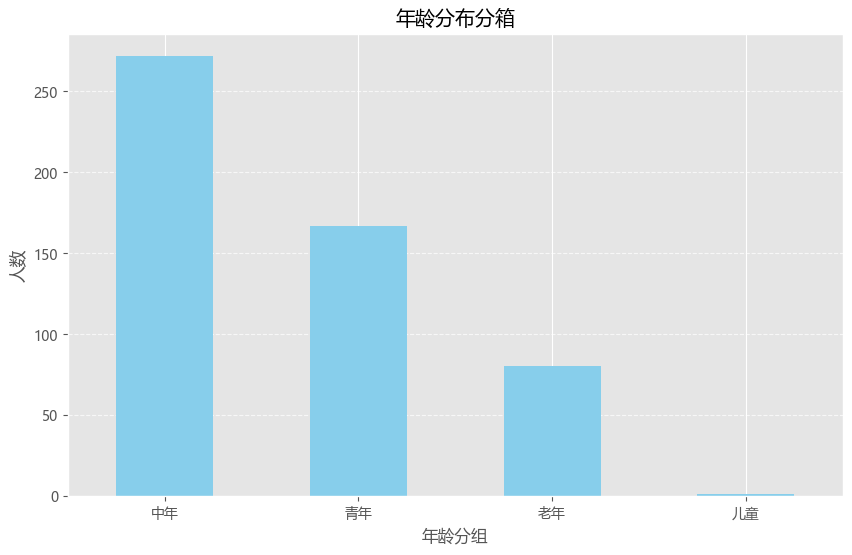


包含分箱结果的数据前5行:
   Age Age_Group
0   40        青年
1   58        中年
2   41        中年
3   45        中年
4   60        中年


In [16]:
# ---------------------- 11. 数据分箱（pd.cut） ----------------------
print("\n---------------------- 数据分箱 ----------------------")
# 年龄分箱区间（儿童、青年、中年、老年）
bins = [0, 18, 40, 60, 120]
labels = ['儿童', '青年', '中年', '老年']

# 分箱操作
age_bins = pd.cut(age_data['Age'], bins=bins, labels=labels)

# 统计各区间数量（修复警告：使用pd.Series包装后调用value_counts）
bin_counts = pd.Series(age_bins).value_counts()
print("年龄分箱结果统计:")
print(bin_counts)

# 可视化分箱结果
plt.figure(figsize=(10, 6))
bin_counts.plot(kind='bar', color='skyblue')
plt.title('年龄分布分箱')
plt.xlabel('年龄分组')
plt.ylabel('人数')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 生成包含分箱结果的数据框
result_df = pd.DataFrame({
    'Age': age_data['Age'],
    'Age_Group': age_bins
})
print("\n包含分箱结果的数据前5行:")
print(result_df.head())
    